### Procesamiento de Lenguaje Natural I
# **Desafío 2**
## Custom embeddings con Gensim

## **Consigna**

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reducción de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable `MAX_WORDS`) de forma tal que la visualización sea adecuada.
- Inspeccionar el gráfico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas.

In [ ]:
# Necesario en Colab. En local las dependencias ya vienen del entorno (uv sync).
%pip install -q gensim numpy scikit-learn matplotlib plotly

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import re
import time
import unicodedata
import urllib.request
from pathlib import Path

import numpy as np

---
## 1. Corpus

Usamos como corpus los cinco libros publicados de **_A Song of Ice and Fire_** de George R. R. Martin
(la saga en la que se basa *Game of Thrones*), en inglés y en texto plano.

Es un corpus interesante para entrenar embeddings propios por varias razones:

- Tiene aproximadamente 1,7 millones de tokens. Es suficiente para que Word2Vec aprenda vectores estables, y a la vez lo bastante chico como para entrenar en pocos minutos en CPU.
- Tiene nombres de personajes, casas nobles, ciudades y castillos inventados. Ningún embedding preentrenado de propósito general conoce estas palabras, así que los vectores solo pueden salir de este corpus.
- La saga tiene familias, títulos, regiones y objetos que se repiten sistemáticamente en los mismos contextos. Esto debería producir agrupamientos claros y fáciles de interpretar en la visualización 2D.

Los archivos vienen del dataset público de Kaggle [*Game of Thrones Books*](https://www.kaggle.com/datasets/khulasasndh/game-of-thrones-books), que descarga una carpeta `archive/` con cinco `.txt` numerados `got1..got5`. La numeración de los archivos **no** sigue el orden de publicación, así que la corregimos abajo.

In [ ]:
CORPUS_DIR = Path('archive')
BASE_URL = 'https://raw.githubusercontent.com/marcoslund/ceia-nlp1/main/desafio_2/archive'

# Los archivos got1..got5 no están en orden de publicación: los mapeamos al título real.
LIBROS = [
    ('got5.txt', 'A Game of Thrones'),
    ('got1.txt', 'A Clash of Kings'),
    ('got2.txt', 'A Storm of Swords'),
    ('got4.txt', 'A Feast for Crows'),
    ('got3.txt', 'A Dance with Dragons'),
]

# En local los archivos ya están en el repo; en Colab los bajamos.
CORPUS_DIR.mkdir(exist_ok=True)
for archivo, _ in LIBROS:
    destino = CORPUS_DIR / archivo
    if destino.exists():
        continue
    print(f'Descargando {archivo}...')
    urllib.request.urlretrieve(f'{BASE_URL}/{archivo}', destino)

print('Archivos disponibles:', sorted(p.name for p in CORPUS_DIR.glob('*.txt')))

Archivos disponibles: ['got1.txt', 'got2.txt', 'got3.txt', 'got4.txt', 'got5.txt']


---
## 2. Preprocesamiento

Cada `.txt` es el libro completo tal como salió del e-book, con un párrafo por línea. Eso trae
material que no es narrativa y que conviene sacar antes de entrenar:

- **Adelante**: portada, página de copyright, índice y lista de mapas.
- **Atrás**: apéndice con el listado de casas nobles, agradecimientos y biografía del autor.

El paratexto editorial es corto pero muy repetitivo, y al repetirse en los cinco libros supera el umbral de frecuencia mínima y termina en el vocabulario. Concretamente, sin recortarlo la palabra `house` queda contaminada por *"Random **House**, **Inc.**"* que no tiene nada que ver con las casas nobles de la saga.

En los cinco libros el cuerpo narrativo arranca en la **última** línea que dice exactamente `PROLOGUE` (la primera aparición es la entrada del índice) y termina en la primera de `APPENDIX` / `ACKNOWLEDGMENTS` / `ABOUT THE AUTHOR`. Usamos esos marcadores para recortar.

In [ ]:
MARCADORES_FIN = {'APPENDIX', 'ACKNOWLEDGMENTS', 'ABOUT THE AUTHOR'}

# El e-book usa comillas y guiones tipográficos; los pasamos a ASCII para que el tokenizador
# no corte palabras como "don't" en dos.
TRADUCCION = str.maketrans({'‘': "'", '’': "'", '“': '"', '”': '"', '—': ' ', '–': ' ', '…': ' '})


def cargar_cuerpo(ruta):
    """Devuelve los párrafos narrativos del libro, sin paratexto editorial."""
    texto = unicodedata.normalize('NFKC', ruta.read_text(encoding='utf-8')).translate(TRADUCCION)
    lineas = texto.split('\n')
    inicio = max(i for i, l in enumerate(lineas) if l.strip() == 'PROLOGUE')
    fin = next(i for i, l in enumerate(lineas) if i > inicio and l.strip() in MARCADORES_FIN)
    return [l.strip() for l in lineas[inicio + 1:fin] if l.strip()]


parrafos_por_libro = {titulo: cargar_cuerpo(CORPUS_DIR / archivo) for archivo, titulo in LIBROS}

print(f'{"Libro":24s} {"Párrafos":>9s} {"Palabras":>10s}')
for titulo, parrafos in parrafos_por_libro.items():
    n_palabras = sum(len(p.split()) for p in parrafos)
    print(f'{titulo:24s} {len(parrafos):9,d} {n_palabras:10,d}')

Libro                     Párrafos   Palabras
A Game of Thrones            6,818    293,794
A Clash of Kings             7,742    322,025
A Storm of Swords            9,656    418,793
A Feast for Crows            7,786    309,227
A Dance with Dragons        10,199    425,065


Word2Vec necesita una lista de documentos tokenizados y usa una ventana de contexto que no debería cruzar fronteras semánticas. Un párrafo entero es una unidad demasiado grande (algunos tienen más de 100 palabras), así que partimos en oraciones: así la ventana solo ve palabras que
realmente comparten contexto.

Para tokenizar usamos una expresión regular que se queda con secuencias de letras admitiendo un apóstrofo interno (`don't`, `lannister's` quedan como un solo token). Eso descarta números y puntuación, que no aportan a los embeddings. Descartamos también las oraciones de menos de 3
tokens, que son casi todas encabezados o interjecciones sueltas.

In [ ]:
# Cortamos después de . ! ? o comilla de cierre, siempre que siga un espacio.
RE_ORACION = re.compile(r'(?<=[.!?"])\s+')
RE_TOKEN = re.compile(r"[a-z]+(?:'[a-z]+)?")
MIN_TOKENS_ORACION = 3

oraciones = []
for parrafos in parrafos_por_libro.values():
    for parrafo in parrafos:
        for oracion in RE_ORACION.split(parrafo):
            tokens = RE_TOKEN.findall(oracion.lower())
            if len(tokens) >= MIN_TOKENS_ORACION:
                oraciones.append(tokens)

largos = np.array([len(o) for o in oraciones])
print(f'Oraciones (documentos): {len(oraciones):,}')
print(f'Tokens totales:         {largos.sum():,}')
print(f'Largo de oración: media={largos.mean():.1f}  mediana={np.median(largos):.0f}  '
      f'p95={np.percentile(largos, 95):.0f}  max={largos.max()}')

Oraciones (documentos): 154,032
Tokens totales:         1,731,367
Largo de oración: media=11.2  mediana=9  p95=27  max=129


In [ ]:
# Un vistazo a cómo quedaron los documentos
for o in oraciones[:5]:
    print(o)

['we', 'should', 'start', 'back']
['gared', 'urged', 'as', 'the', 'woods', 'began', 'to', 'grow', 'dark', 'around', 'them']
['the', 'wildlings', 'are', 'dead']
['do', 'the', 'dead', 'frighten', 'you']
['ser', 'waymar', 'royce', 'asked', 'with', 'just', 'the', 'hint', 'of', 'a', 'smile']


El corpus quedó en **~154.000 oraciones y ~1,73 millones de tokens**, con una mediana de 9 tokens
por oración. Es un largo típico de narrativa con mucho diálogo, y encaja bien con la ventana de
contexto que vamos a usar.

---
## 3. Entrenamiento de los embeddings

Entrenamos un **Skip-gram con negative sampling**. Skip-gram predice el contexto a partir de la
palabra central, lo que lo hace más lento que CBOW pero mejor con palabras poco frecuentes — y en
este corpus muchos de los términos interesantes (nombres de personajes secundarios, castillos)
aparecen pocas veces.

Hiperparámetros:

| Parámetro | Valor | Motivo |
|---|---|---|
| `sg=1` | Skip-gram | Mejor para vocabulario de baja frecuencia. En la sección 5 lo comparamos contra CBOW. |
| `vector_size=200` | 200 dimensiones | Con 300 los vecinos son prácticamente los mismos y tarda 2,4× más. |
| `window=5` | ±5 palabras | Con una mediana de 9 tokens por oración, la ventana cubre casi toda la oración. |
| `min_count=10` | frecuencia mínima | Deja 8.344 palabras. Con umbrales menores entran nombres que aparecen 2 o 3 veces y cuyos vectores son puro ruido. |
| `negative=10` | negative sampling | Valor habitual para corpus medianos. |
| `workers=1`, `seed=42` | 1 solo hilo | Word2Vec solo es reproducible con un único worker: con varios hilos el orden de las actualizaciones varía entre corridas. Preferimos que el notebook dé siempre el mismo resultado antes que ganar velocidad. |
| `epochs=10` | 10 pasadas | Con 20 los vecinos se dispersan sin mejorar la interpretación. |

In [ ]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec


class ReporteLoss(CallbackAny2Vec):
    """Imprime la loss de cada época (gensim solo expone el acumulado)."""

    def __init__(self):
        self.epoca = 0
        self.loss_previa = 0.0

    def on_epoch_end(self, model):
        loss_acumulada = model.get_latest_training_loss()
        print(f'Loss época {self.epoca:2d}: {loss_acumulada - self.loss_previa:12,.0f}   '
              f'(acumulada {loss_acumulada:14,.0f})')
        self.epoca += 1
        self.loss_previa = loss_acumulada

In [ ]:
w2v = Word2Vec(
    min_count=10,      # frecuencia mínima de palabra para incluirla en el vocabulario
    window=5,          # cant. de palabras antes y después de la predicha
    vector_size=200,   # dimensionalidad de los vectores
    negative=10,       # cantidad de negative samples
    workers=1,         # 1 solo worker para que el entrenamiento sea reproducible
    seed=42,
    sg=1,              # 0: CBOW   1: Skip-gram
)

w2v.build_vocab(oraciones)
print(f'Documentos en el corpus: {w2v.corpus_count:,}')
print(f'Palabras distintas en el vocabulario (min_count=10): {len(w2v.wv.index_to_key):,}')

Documentos en el corpus: 154,032
Palabras distintas en el vocabulario (min_count=10): 8,344


In [ ]:
# Las 25 palabras más frecuentes del vocabulario
frecuencias = [(w, w2v.wv.get_vecattr(w, 'count')) for w in w2v.wv.index_to_key]
print(', '.join(f'{w} ({c:,})' for w, c in frecuencias[:25]))

cubiertos = sum(c for _, c in frecuencias)
print(f'\nCobertura del vocabulario sobre el corpus: {100 * cubiertos / largos.sum():.1f}% de los tokens')

the (102,757), and (51,932), to (39,704), a (39,638), of (36,546), he (26,576), his (26,256), was (21,964), her (18,997), you (18,933), i (18,377), in (17,933), had (16,910), it (16,179), that (15,744), as (15,059), she (14,072), with (13,192), him (12,376), not (11,484), but (11,214), for (10,799), is (9,091), on (8,881), they (8,878)

Cobertura del vocabulario sobre el corpus: 97.3% de los tokens


In [ ]:
t0 = time.time()
w2v.train(
    oraciones,
    total_examples=w2v.corpus_count,
    epochs=10,
    compute_loss=True,
    callbacks=[ReporteLoss()],
)
print(f'\nTiempo de entrenamiento: {time.time() - t0:.0f} s')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss época  0:   13,706,177   (acumulada     13,706,177)


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss época  1:   11,249,287   (acumulada     24,955,464)


Loss época  2:   10,925,980   (acumulada     35,881,444)


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Loss época  7:      557,264   (acumulada     68,258,880)


Loss época  8:      533,760   (acumulada     68,792,640)


Loss época  9:      510,360   (acumulada     69,303,000)

Tiempo de entrenamiento: 93 s


El entrenamiento tarda alrededor de 90 segundos y la loss baja de forma monótona (13,7 M → 0,5 M).

---
## 4. Términos de interés

Elegimos cinco términos que cubren ejes semánticos distintos de la saga, para ver si los
embeddings capturan cosas diferentes en cada caso:

| Término | Eje que queremos sondear |
|---|---|
| `daenerys` | **Personaje**. ¿Recupera sus títulos y su entorno, u otros personajes? |
| `house` | **Institución**. ¿Aparece el vocabulario heráldico y las casas nobles? |
| `dragons` | **Objeto/criatura ligada a una trama**. ¿Queda pegado a la línea narrativa de Daenerys? |
| `king` | **Título y poder**. ¿Recupera reyes concretos y vocabulario de sucesión? |
| `wall` | **Lugar**. ¿Se comporta como topónimo (el Muro) o como sustantivo común (una pared)? |

Para cada uno buscamos los 10 términos **más similares** (`most_similar(positive=[...])`) y los 10
**menos similares** (`most_similar(negative=[...])`).

In [11]:
def analizar(termino, topn=10):
    frecuencia = w2v.wv.get_vecattr(termino, 'count')
    print(f'=== {termino.upper()}  (aparece {frecuencia:,} veces)')
    print('  MÁS similares:')
    for palabra, sim in w2v.wv.most_similar(positive=[termino], topn=topn):
        print(f'    {palabra:16s} {sim:+.3f}   ({w2v.wv.get_vecattr(palabra, "count"):,} apariciones)')
    print('  MENOS similares:')
    for palabra, sim in w2v.wv.most_similar(negative=[termino], topn=topn):
        print(f'    {palabra:16s} {sim:+.3f}   ({w2v.wv.get_vecattr(palabra, "count"):,} apariciones)')
    print()


TERMINOS_INTERES = ['daenerys', 'house', 'dragons', 'king', 'wall']
for termino in TERMINOS_INTERES:
    analizar(termino)

=== DAENERYS  (aparece 296 veces)
  MÁS similares:
    stormborn        +0.700   (22 apariciones)
    unburnt          +0.649   (13 apariciones)
    targaryen        +0.629   (243 apariciones)
    khaleesi         +0.591   (115 apariciones)
    unworthy         +0.572   (21 apariciones)
    hatched          +0.542   (10 apariciones)
    dany             +0.536   (1,094 apariciones)
    kneel            +0.535   (54 apariciones)
    rosey            +0.524   (17 apariciones)
    meereen          +0.517   (276 apariciones)
  MENOS similares:
    stout            +0.075   (74 apariciones)
    crooked          +0.074   (77 apariciones)
    flint            +0.054   (88 apariciones)
    fingered         +0.054   (28 apariciones)
    hacked           +0.054   (71 apariciones)
    clad             +0.044   (138 apariciones)
    armory           +0.039   (87 apariciones)
    scratched        +0.038   (55 apariciones)
    hempen           +0.036   (24 apariciones)
    kegs             +0.036   

**`daenerys`** — El modelo reconstruye muchos de sus títulos: *Daenerys **Stormborn**,
the **Unburnt***, `khaleesi` (su título dothraki), el apellido `targaryen`, su apodo `dany` y
`meereen`, la ciudad que gobierna. El caso de `rosey` (17 apariciones, un personaje menor sin
relación alguna) muestra que con tan pocas ocurrencias los vectores son inestables y aparece ruido.

**`house`** — Sale todo el vocabulario heráldico y feudal: `sigil`, `badge`, `falcon` (el
emblema de los Arryn), `bannerman`, `stronghold`, más apellidos de casas menores (`westerling`) y
miembros de esas casas (`gawen`, `alannys`). El modelo aprendió el sentido institucional de la
palabra, no el de edificio.

**`dragons`** — Queda pegado a la línea narrativa de Daenerys en Essos: `hatched`, `unburnt`,
`stormborn`, `daenerys`, `warlocks`, `khals`, y `shackles` (la trama de la esclavitud en la Bahía
de los Esclavos). Es un buen ejemplo de que Word2Vec captura co-ocurrencia narrativa y no
taxonomía: el singular `dragon`, que sería el vecino "obvio", queda recién tercero.

**`king`** — Domina el vocabulario de sucesión y legitimidad: `pretender`, `regent`, `usurper`,
`proclaim`, `issue` (en su acepción legal de "descendencia"), y reyes concretos (`baratheon`,
`aerys`, `jaehaerys`, `cleon`). El `ii` en primer lugar viene de reyes como Jaehaerys II y Aerys II.
Llamativamente no aparecen `queen` ni `throne`.

**`wall`** — Se resuelve como topónimo (el Muro del Norte), no como sustantivo común:
`greyguard` (uno de los castillos de la Guardia de la Noche), `milkwater` (un río más allá del
Muro), `wildlings` (quienes viven del otro lado). Pero conviven con palabras genéricas de
"estructura vertical" (`cliff`, `watchtower`, `heights`, `climbers`).

Sobre los términos "menos similares", el patrón es el mismo en los cinco casos y es más
interesante de lo que parece: ninguna similaridad es realmente negativa (los mínimos van de
+0,006 a +0,075). En un espacio de 200 dimensiones entrenado con negative sampling no existen
"opuestos": lo que se obtiene son palabras simplemente no relacionadas, de otro dominio, y no antónimos.

---
Dos comprobaciones rápidas más. Primero, la similaridad coseno directa entre pares elegidos a mano
para ver si el modelo separa relaciones fuertes de relaciones débiles. Segundo, `doesnt_match`,
que dentro de un conjunto devuelve la palabra más lejana al centroide: es una forma barata de
verificar si el espacio realmente agrupa por categoría.

In [ ]:
PARES = [
    ('daenerys', 'dragons'),
    ('daenerys', 'winterfell'),
    ('jon', 'wall'),
    ('jon', 'dragons'),
    ('house', 'sigil'),
    ('king', 'throne'),
    ('wall', 'wildlings'),
    ('wall', 'wine'),
]
print('Similaridad coseno entre pares:')
for a, b in PARES:
    print(f'  {a:10s} <-> {b:12s} {w2v.wv.similarity(a, b):+.3f}')

Similaridad coseno entre pares:
  daenerys   <-> dragons      +0.487
  daenerys   <-> winterfell   +0.228
  jon        <-> wall         +0.323
  jon        <-> dragons      +0.016
  house      <-> sigil        +0.502
  king       <-> throne       +0.382
  wall       <-> wildlings    +0.492
  wall       <-> wine         +0.106


In [13]:
GRUPOS = [
    ['stark', 'lannister', 'tyrell', 'sword'],          # casas nobles + un objeto
    ['winterfell', 'riverrun', 'highgarden', 'arya'],   # castillos + una persona
    ['red', 'green', 'blue', 'horse'],                  # colores + un animal
    ['sword', 'axe', 'dagger', 'bread'],                # armas + comida
    ['jon', 'arya', 'bran', 'dragon'],                  # hermanos Stark + una criatura
]
print('Detección del intruso (doesnt_match):')
for grupo in GRUPOS:
    print(f'  {str(grupo):55s} -> {w2v.wv.doesnt_match(grupo)}')

Detección del intruso (doesnt_match):
  ['stark', 'lannister', 'tyrell', 'sword']               -> sword
  ['winterfell', 'riverrun', 'highgarden', 'arya']        -> arya
  ['red', 'green', 'blue', 'horse']                       -> horse
  ['sword', 'axe', 'dagger', 'bread']                     -> bread
  ['jon', 'arya', 'bran', 'dragon']                       -> dragon


Las similaridades por pares permiten identificar si dos elementos comparten línea narrativa:

- `daenerys` ↔ `dragons` (**+0,487**) contra `daenerys` ↔ `winterfell` (**+0,228**): los dragones
  son su trama; en Winterfell nunca pone un pie.
- `jon` ↔ `wall` (**+0,323**) contra `jon` ↔ `dragons` (**+0,016**). Las tramas del Norte y de Essos
  casi no comparten escena.

`doesnt_match` acierta en los cinco casos, por lo que el espacio agrupa bien por categoría.

---
## 5. Experimento adicional: Skip-gram vs CBOW

Entrenamos un segundo modelo idéntico pero con `sg=0` (CBOW, que predice la palabra central a
partir del contexto) y comparamos los vecinos de los mismos cinco términos.

In [15]:
t0 = time.time()
cbow = Word2Vec(
    oraciones,
    min_count=10, window=5, vector_size=200, negative=10,
    workers=1, seed=42, sg=0, epochs=10,
)
print(f'Tiempo de entrenamiento CBOW: {time.time() - t0:.0f} s\n')

for termino in TERMINOS_INTERES:
    print(f'{termino.upper()}')
    print('  skip-gram :', ', '.join(p for p, _ in w2v.wv.most_similar(termino, topn=8)))
    print('  cbow      :', ', '.join(p for p, _ in cbow.wv.most_similar(termino, topn=8)))
    print()

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Tiempo de entrenamiento CBOW: 28 s

DAENERYS
  skip-gram : stormborn, unburnt, targaryen, khaleesi, unworthy, hatched, dany, kneel
  cbow      : targaryen, aerys, aegon, queen, viserys, myrcella, margaery, stormborn

HOUSE
  skip-gram : sigil, owes, gawen, stronghold, falcon, westerling, queensguard, bannerman
  cbow      : stronghold, banner, sigil, vale, highgarden, castellan, bannerman, martyn

DRAGONS
  skip-gram : hatched, unburnt, dragon, stormborn, shackles, pureborn, daenerys, warlocks
  cbow      : dreams, children, dragon, slaves, dornishmen, eunuchs, whores, singers

KING
  skip-gram : ii, pretender, regent, baratheon, usurper, aerys, jaehaerys, cleon
  cbow      : baratheon, realm, usurper, heir, conqueror, beloved, warrior, rebellion

WALL
  skip-gram : greyguard, climbers, wildlings, milkwater, watchtower, cliff, heights, foothills
  cbow      : battlements, mountain, kingsroad, shore, ground, walls, road, bridge



CBOW tarda **~26 s** contra los **~90 s** de Skip-gram, tres veces más rápido. No aprenden lo
mismo, y el patrón es consistente en los cinco términos:

| Término | Skip-gram devuelve… | CBOW devuelve… |
|---|---|---|
| `daenerys` | sus títulos: `stormborn`, `unburnt`, `khaleesi` | otros nobles y reyes: `aerys`, `aegon`, `viserys`, `margaery` |
| `dragons` | su trama: `hatched`, `unburnt`, `warlocks` | otros plurales de colectivos: `children`, `slaves`, `eunuchs`, `singers` |
| `wall` | el lugar concreto: `greyguard`, `milkwater`, `wildlings` | accidentes geográficos genéricos: `battlements`, `mountain`, `shore`, `road` |

En estos resultados Skip-gram devuelve lo que literalmente acompaña a la palabra en el texto y CBOW palabras intercambiables en la misma posición, del mismo "tipo".

---
## 6. Reducción de dimensionalidad y visualización 2D

Proyectamos los vectores de 200 dimensiones a 2 con **t-SNE**.

Dos decisiones sobre qué palabras graficar:

1. Corremos t-SNE sobre el subconjunto que vamos a graficar, no sobre las 8.344 palabras.
2. Filtramos las stopwords inglesas, dejando mayormente palabras con contenido.

In [18]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.manifold import TSNE

# Restos de contracciones que deja el tokenizador + un verbo omnipresente en narrativa
STOPWORDS_EXTRA = {'said', 'll', 've', 're', 'don', 'didn', 'wouldn', 'couldn', 'isn', 'wasn', 'doesn'}
STOPWORDS = set(ENGLISH_STOP_WORDS) | STOPWORDS_EXTRA


def palabras_a_graficar(modelo, max_words):
    """Las `max_words` palabras más frecuentes con contenido semántico."""
    return [
        palabra for palabra in modelo.wv.index_to_key
        if palabra not in STOPWORDS and "'" not in palabra and len(palabra) > 2
    ][:max_words]


def proyectar(modelo, palabras, n_dim=2, perplexity=30, random_state=0):
    """Proyecta a `n_dim` con t-SNE, ajustando solo sobre las palabras pedidas."""
    vectores = np.asarray([modelo.wv[p] for p in palabras])
    tsne = TSNE(n_components=n_dim, random_state=random_state,
                perplexity=perplexity, init='pca')
    return tsne.fit_transform(vectores)

### 6.1 Elección de `MAX_WORDS`

La consigna pide elegir `MAX_WORDS` de forma que la visualización sea adecuada. Graficamos tres
valores con el mismo criterio para poder compararlos.

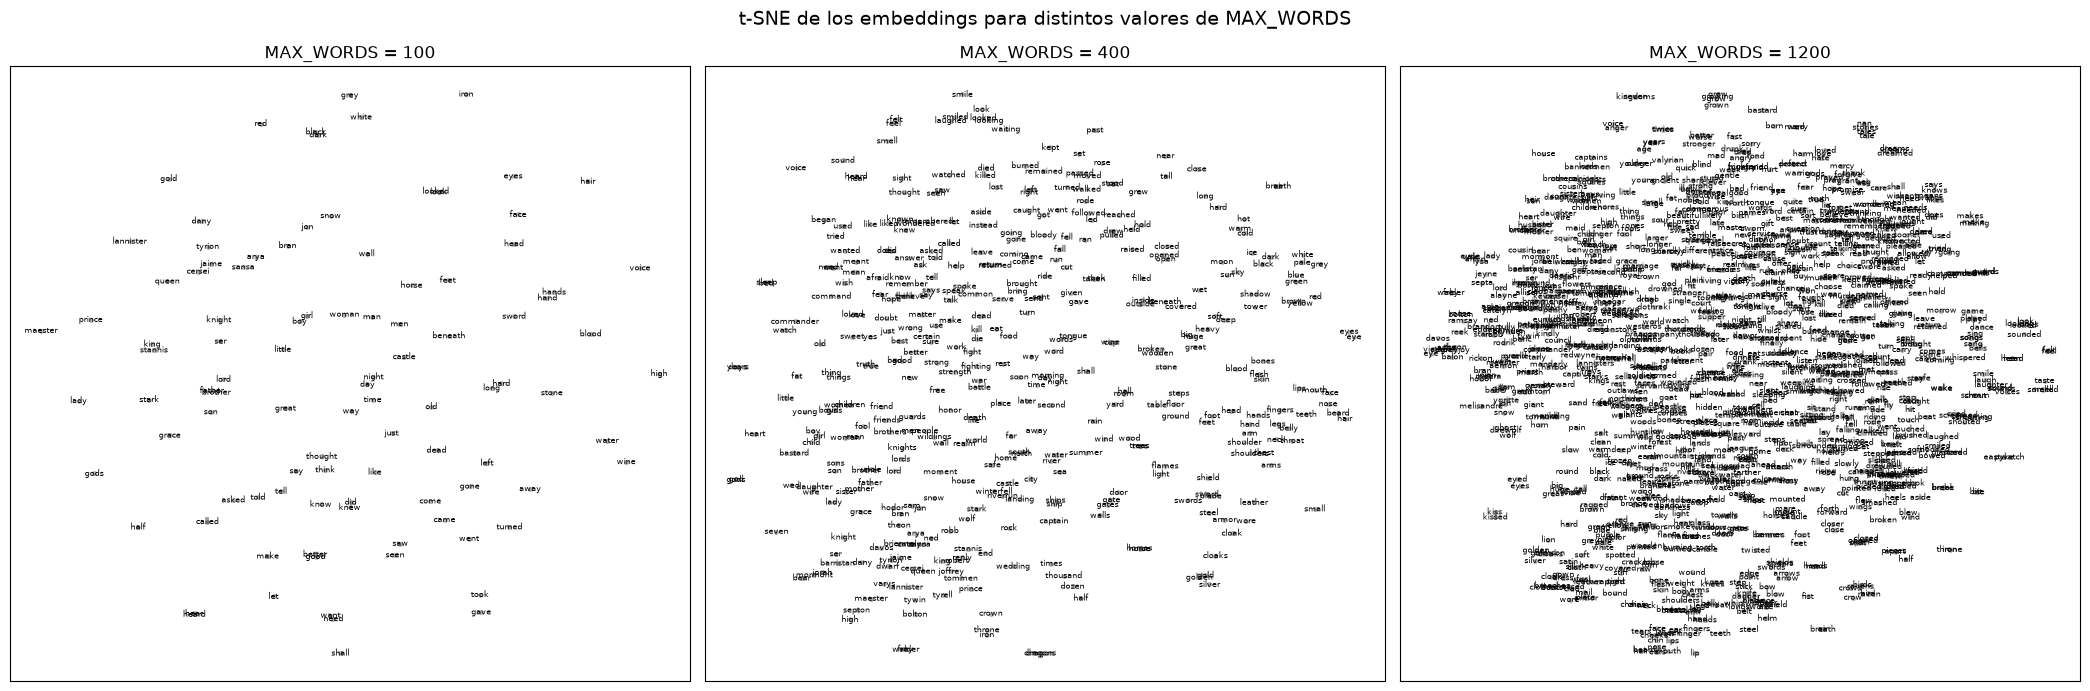

In [19]:
import matplotlib.pyplot as plt

CANDIDATOS = [100, 400, 1200]

fig, axes = plt.subplots(1, len(CANDIDATOS), figsize=(21, 7))
for ax, n in zip(axes, CANDIDATOS):
    palabras_n = palabras_a_graficar(w2v, n)
    xy = proyectar(w2v, palabras_n)
    ax.scatter(xy[:, 0], xy[:, 1], s=6, color='#b0b0b0', zorder=1)
    for (x, y), palabra in zip(xy, palabras_n):
        ax.text(x, y, palabra, fontsize=6, ha='center', va='center', zorder=2)
    ax.set_title(f'MAX_WORDS = {n}')
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle('t-SNE de los embeddings para distintos valores de MAX_WORDS', fontsize=14)
plt.tight_layout()
plt.show()

- Con `MAX_WORDS = 100` se lee cada etiqueta, pero no se ven grupos.
- Con `MAX_WORDS = 1200` las etiquetas se superponen por completo. Hay estructura, pero es
  ilegible, y con 1200 palabras ya entran términos de pocas apariciones cuyos vectores son ruidosos.
- Con `MAX_WORDS = 400` llegamos a un punto de equilibrio. Hay suficientes puntos para que se formen
  regiones y todavía se puede leer.

Nos quedamos con `MAX_WORDS = 400`. La palabra menos frecuente incluida es `girls`, con 322
apariciones: todo lo que se grafica aparece al menos 300 veces, así que los vectores están bien
estimados y lo que veamos no va a ser ruido de baja frecuencia.

In [20]:
MAX_WORDS = 400

palabras = palabras_a_graficar(w2v, MAX_WORDS)
proyeccion_2d = proyectar(w2v, palabras)
print(f'Palabras graficadas: {len(palabras)}')
print(f'Menos frecuente de las incluidas: {palabras[-1]!r} '
      f'({w2v.wv.get_vecattr(palabras[-1], "count"):,} apariciones)')

Palabras graficadas: 400
Menos frecuente de las incluidas: 'girls' (322 apariciones)


### 6.2 Gráfico estático

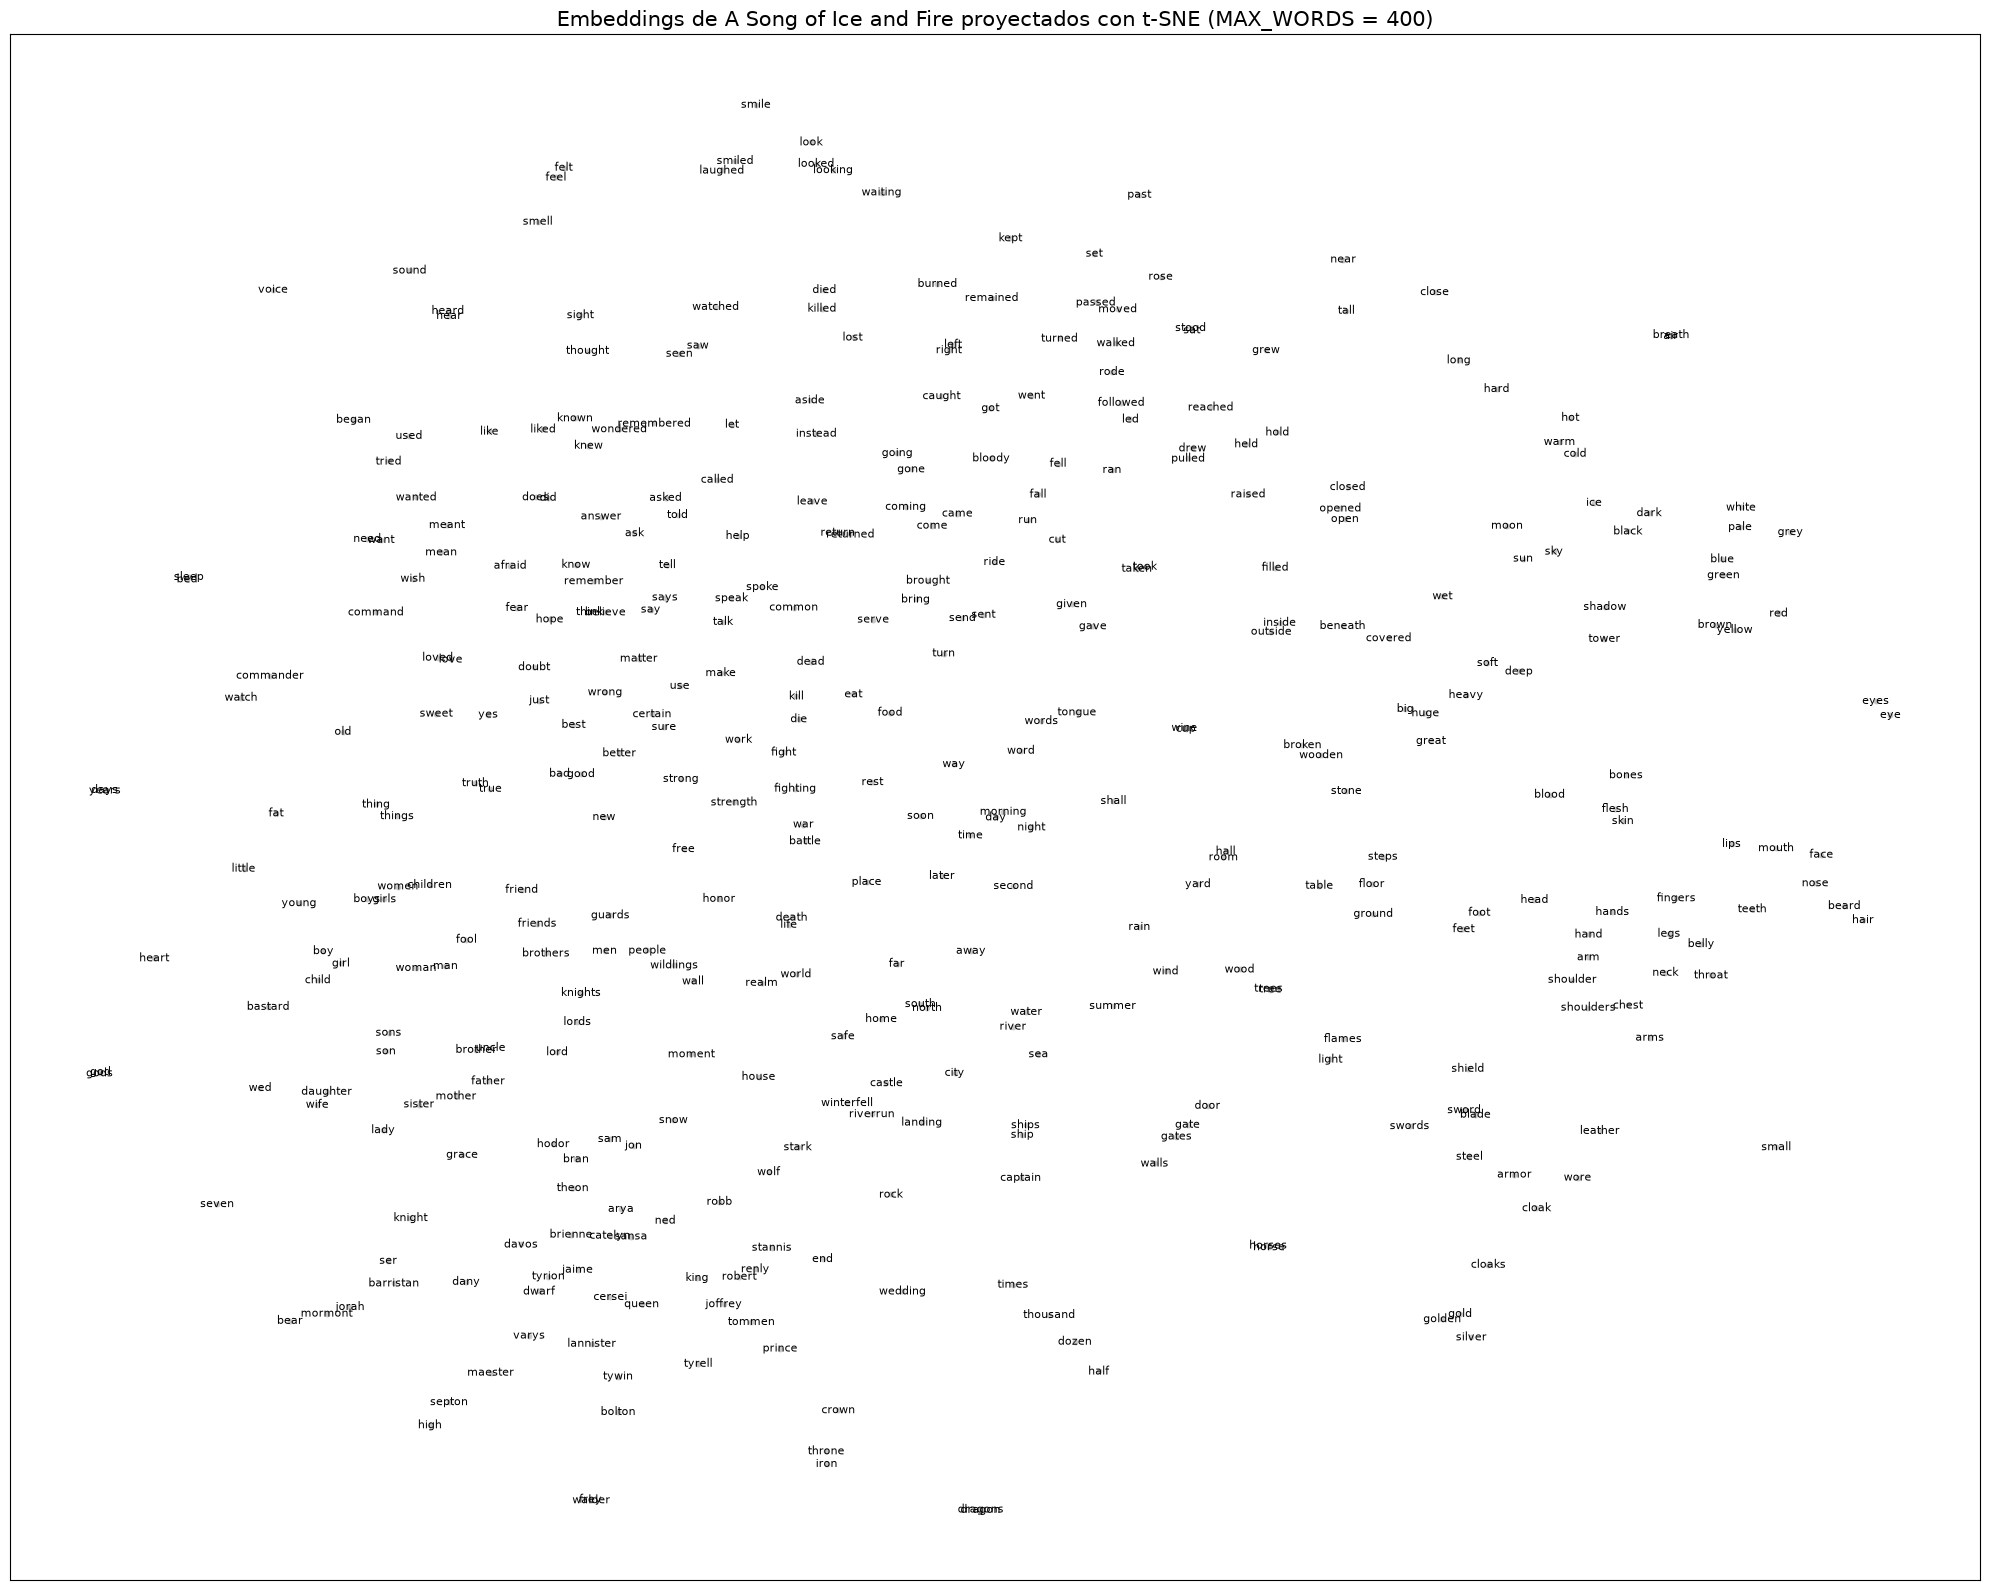

In [19]:
fig, ax = plt.subplots(figsize=(20, 16))
ax.scatter(proyeccion_2d[:, 0], proyeccion_2d[:, 1], s=10, color='#c8c8c8', zorder=1)
for (x, y), palabra in zip(proyeccion_2d, palabras):
    ax.text(x, y, palabra, fontsize=8, ha='center', va='center', zorder=2)
ax.set_title(f'Embeddings de A Song of Ice and Fire proyectados con t-SNE '
             f'(MAX_WORDS = {MAX_WORDS})', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

### 6.3 Gráfico interactivo

In [23]:
import plotly.graph_objects as go

fig = go.Figure(go.Scatter(
    x=proyeccion_2d[:, 0], y=proyeccion_2d[:, 1], text=palabras,
    mode='markers+text', textposition='top center', textfont_size=9,
    marker=dict(size=4, color='#636efa'), hoverinfo='text',
))
fig.update_layout(
    title=f'Embeddings proyectados con t-SNE (MAX_WORDS = {MAX_WORDS})',
    width=1000, height=800,
    xaxis=dict(visible=False), yaxis=dict(visible=False),
)
fig.show()

In [21]:
# Misma proyección en 3D
proyeccion_3d = proyectar(w2v, palabras, n_dim=3)

fig = go.Figure(go.Scatter3d(
    x=proyeccion_3d[:, 0], y=proyeccion_3d[:, 1], z=proyeccion_3d[:, 2], text=palabras,
    mode='markers+text', textfont_size=8, marker=dict(size=2, color='#636efa'), hoverinfo='text',
))
fig.update_layout(
    title=f'Embeddings proyectados con t-SNE en 3D (MAX_WORDS = {MAX_WORDS})',
    width=1000, height=800,
)
fig.show()

### 6.4 Coloreado por clustering

La inspección de los grupos es manual, pero para no depender solo del ojo corremos K-Means sobre
la proyección 2D y coloreamos los puntos por cluster. Cabe aclarar que los clusters se
calculan sobre las coordenadas t-SNE y no sobre los vectores originales, y el número de clusters
es arbitrario.

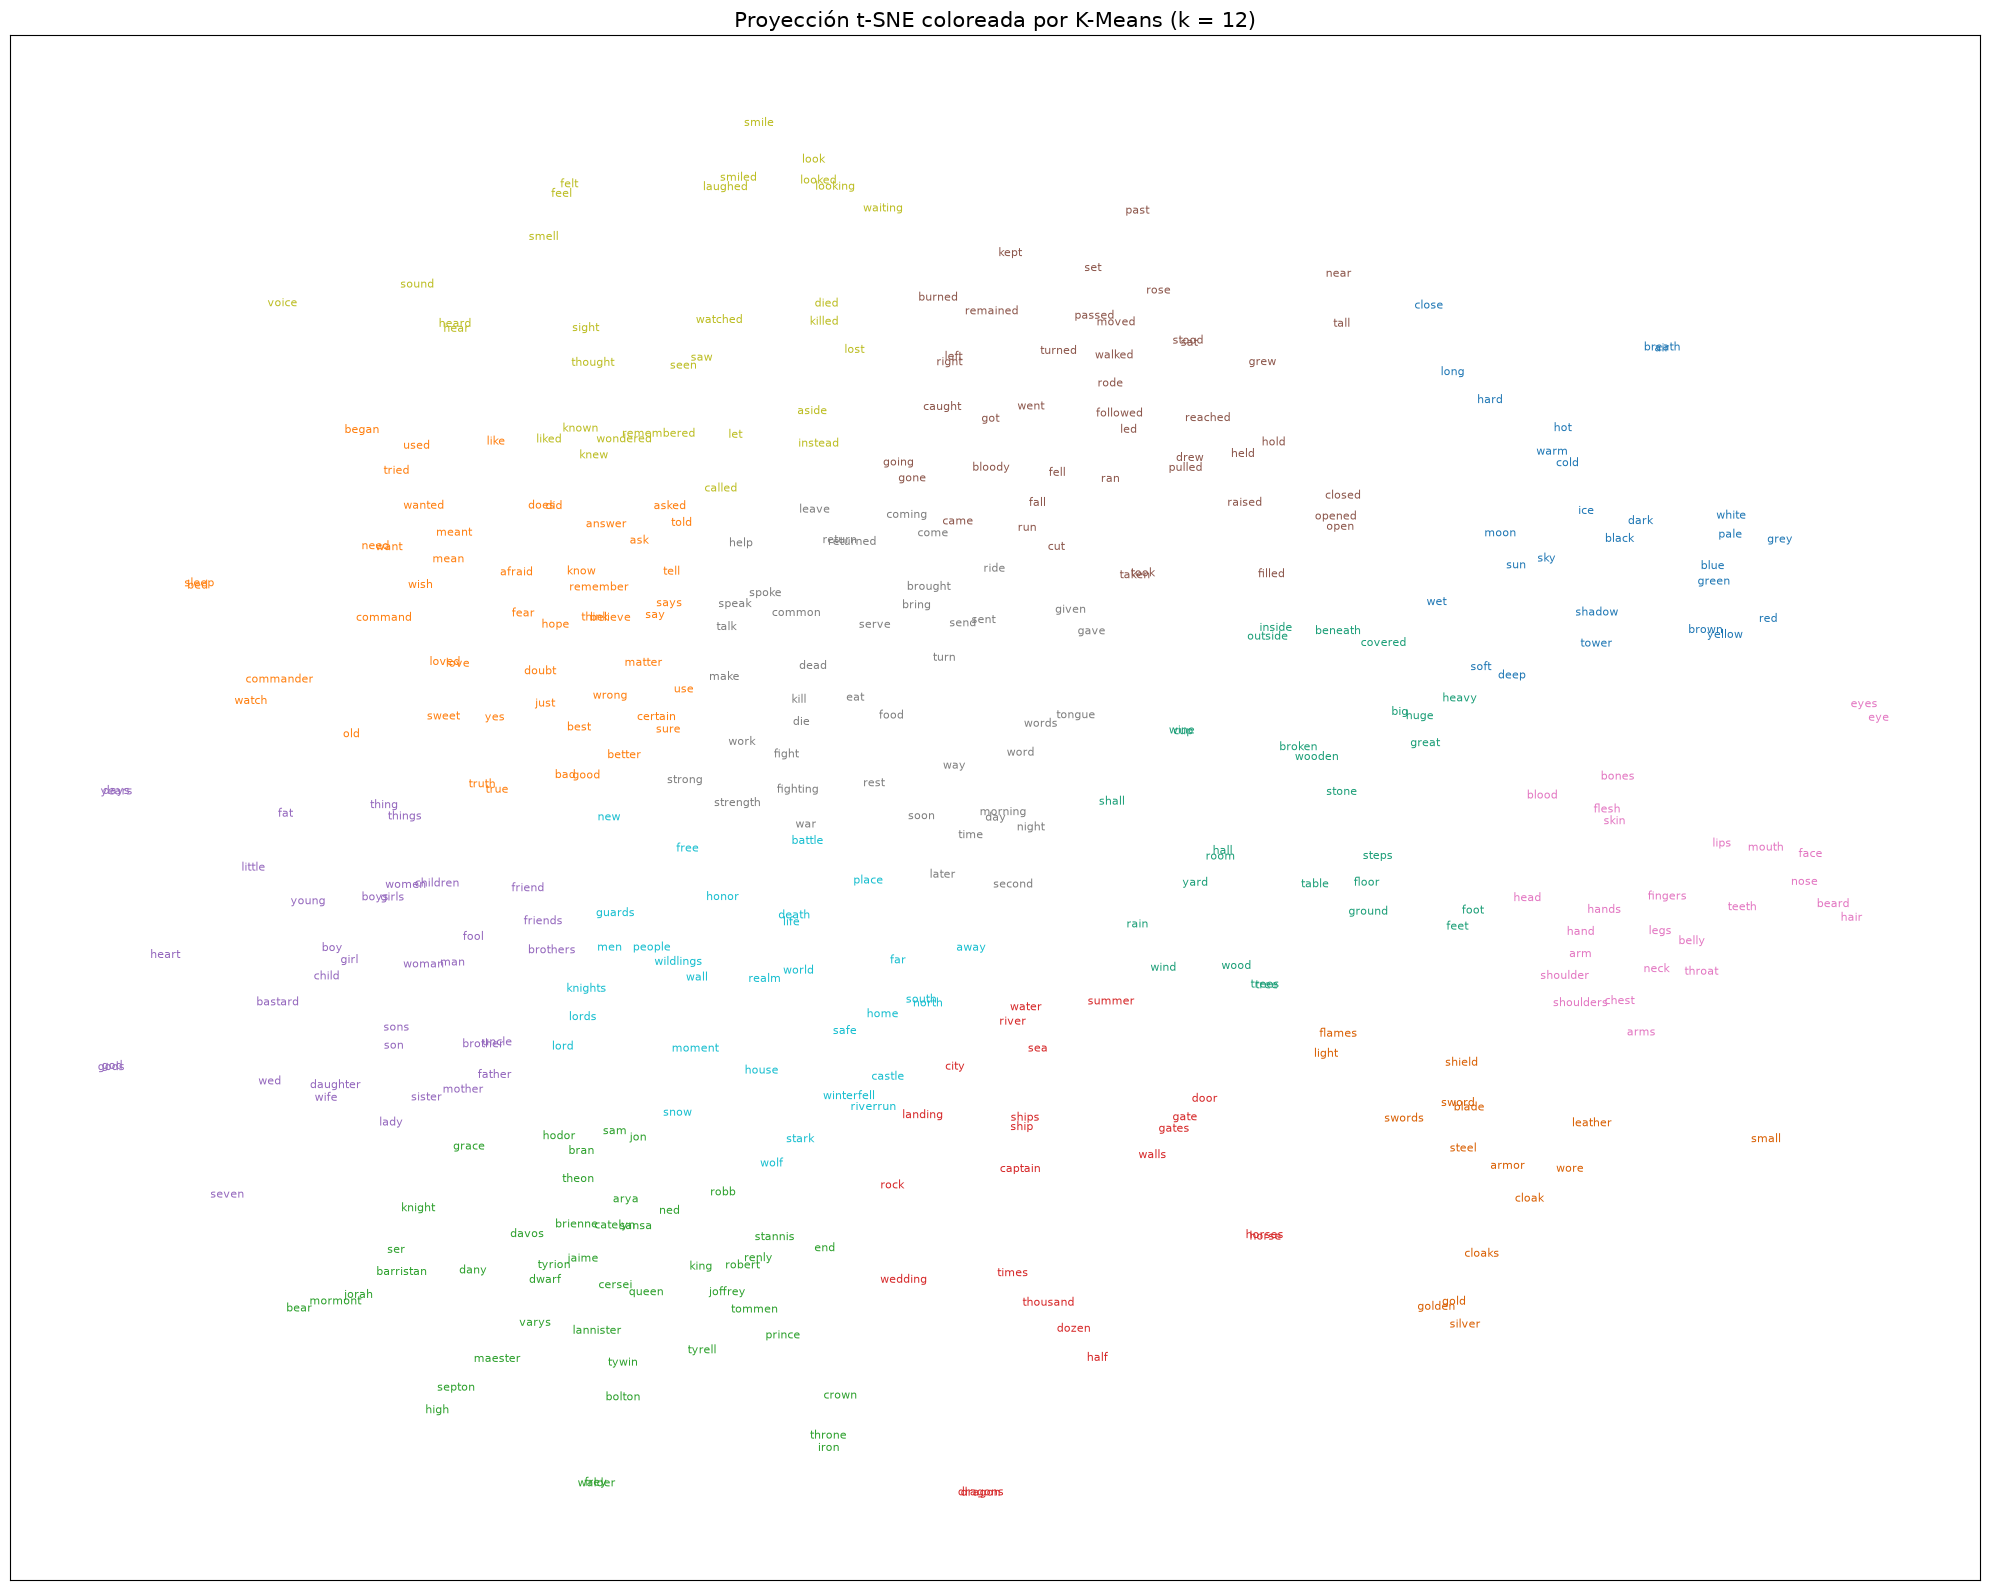

In [22]:
N_CLUSTERS = 12
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=0, n_init=10).fit(proyeccion_2d)

fig, ax = plt.subplots(figsize=(20, 16))
# tab20 alterna tonos oscuros y claros; los claros no se leen sobre fondo blanco,
# así que combinamos dos paletas cualitativas de tonos saturados.
colores = np.vstack([plt.get_cmap('tab10').colors, plt.get_cmap('Dark2').colors])[:N_CLUSTERS]
for (x, y), palabra, etiqueta in zip(proyeccion_2d, palabras, kmeans.labels_):
    ax.text(x, y, palabra, fontsize=8, ha='center', va='center', color=colores[etiqueta])
ax.set_xlim(proyeccion_2d[:, 0].min() - 3, proyeccion_2d[:, 0].max() + 3)
ax.set_ylim(proyeccion_2d[:, 1].min() - 3, proyeccion_2d[:, 1].max() + 3)
ax.set_title(f'Proyección t-SNE coloreada por K-Means (k = {N_CLUSTERS})', fontsize=15)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

In [23]:
# Listado de cada cluster, ordenado por frecuencia, para leer los grupos con comodidad
for c in range(N_CLUSTERS):
    del_cluster = [p for p, etiqueta in zip(palabras, kmeans.labels_) if etiqueta == c]
    print(f'[{c:2d}] ({len(del_cluster):3d} palabras) ' + ', '.join(del_cluster))
    print()

[ 0] ( 27 palabras) black, long, red, white, grey, hard, dark, cold, green, tower, pale, close, hot, brown, air, blue, sun, deep, soft, sky, shadow, warm, moon, ice, yellow, breath, wet

[ 1] ( 49 palabras) did, like, old, know, told, good, say, want, tell, need, just, think, asked, better, does, watch, wanted, true, sweet, best, fear, mean, tried, began, love, bed, sleep, certain, ask, hope, meant, command, truth, doubt, yes, remember, matter, believe, answer, used, wish, commander, wrong, says, loved, use, afraid, bad, sure

[ 2] ( 46 palabras) ser, jon, king, tyrion, queen, arya, jaime, maester, knight, sansa, bran, dany, stannis, grace, high, prince, iron, cersei, lannister, catelyn, end, robb, sam, robert, ned, joffrey, theon, brienne, davos, tywin, bear, throne, dwarf, jorah, renly, frey, mormont, septon, barristan, tyrell, varys, crown, tommen, bolton, hodor, walder

[ 3] ( 23 palabras) half, horse, water, walls, sea, door, city, horses, thousand, landing, dragons, river, dragon

### 6.5 Exportación para el TensorFlow Projector

Guardamos vectores y etiquetas en `.tsv` para poder explorarlos también en
[projector.tensorflow.org](http://projector.tensorflow.org/).

In [24]:
np.savetxt('vectors.tsv', np.asarray(w2v.wv.vectors), delimiter='\t')
with open('labels.tsv', 'w') as fp:
    fp.writelines(f'{palabra}\n' for palabra in w2v.wv.index_to_key)
print(f'Exportados {w2v.wv.vectors.shape[0]:,} vectores de {w2v.wv.vectors.shape[1]} dimensiones')

Exportados 8,344 vectores de 200 dimensiones


---
## 7. Inspección del gráfico: grupos de palabras

Recorriendo el gráfico interactivo de la sección 6.3 y cruzándolo con el listado de clusters de la
sección 6.4, se identifican seis grupos claramente interpretables. Para cada uno indicamos dónde
está en el mapa, qué palabras lo componen y qué explica que esas palabras hayan quedado juntas.

#### Grupo 1 — Colores y clima


<img src="capturas/colores.png" width="25%">

**Dónde está:** extremo superior derecho del mapa.

**Interpretación:** el subgrupo de colores es el más nítido de todo el mapa. Estos adjetivos comparten un
contexto distribucional prácticamente idéntico: van delante de un sustantivo de ropa, ojos o pelo, por ejemplo.

Dos observaciones:

- `dark` y `pale` no son colores sino grados de luminosidad, y quedan mezclados con los tonos.
- `gold`, `golden` y `silver` sí son colores, y sin embargo no están acá sino en el grupo 3. En este corpus aparecen mucho más como material (monedas de oro, acero plateado) que como color, y el vector sigue al uso, no al diccionario.

Pegado a los colores está el vocabulario atmosférico (`sun`, `moon`, `sky`, `ice`, `cold`, `warm`,
`wet`): es el mismo registro de descripción de ambiente, y por eso el cluster los junta.

#### Grupo 2 — Partes del cuerpo

<img src="capturas/cuerpo.png" width="50%">

**Dónde está:** borde derecho del mapa, debajo de los colores.

**Interpretación:** es el grupo más cohesivo del mapa y el único sin intrusos. El motivo es la
densidad de contexto: la prosa de la saga describe reacciones físicas constantemente
(*"his **hand** closed on the hilt"*, *"her **eyes** went wide"*), con lo cual estos sustantivos
comparten un contexto muy angosto — posesivo + parte del cuerpo + verbo de movimiento.

Dos detalles que dicen algo sobre el método:

- Los pares singular/plural están los dos en el vocabulario y quedan adyacentes
  (`hand`/`hands`, `eye`/`eyes`, `arm`/`arms`, `shoulder`/`shoulders`). El modelo
  los pone juntos únicamente porque comparten contexto.
- `blood` no es una parte del cuerpo, pero aparece en los mismos contextos descriptivos y queda
  dentro.

#### Grupo 3 — Armas, armaduras y atuendo

<img src="capturas/armas-armadura-atuendo.png" width="25%">

**Dónde está:** franja derecha, por debajo de las partes del cuerpo.

**Interpretación:** armas, materiales y prendas en un mismo grupo, más un verbo (`wore`, de vestir).
Por ejemplo se presenta a un caballero por su equipo (*"he **wore** a **cloak** of black wool,
a **silver** clasp at his throat and a longsword at his hip"*). El grupo no es "armas" sino la
descripción de lo que un personaje lleva puesto y encima.

#### Grupo 4 — Personajes y títulos nobiliarios

<img src="capturas/personajes.png" width="50%">

**Dónde está:** cuadrante inferior izquierdo. Es la región más densa del mapa.

**Interpretación:** el grupo más grande, y mezcla nombres propios con títulos. Eso no es ruido: en
el texto un nombre casi nunca aparece solo, aparece como *"**Ser** Jaime"*, *"**Maester** Luwin"*,
*"**Prince** Joffrey"*, *"Your **Grace**"*. Título y nombre son literalmente adyacentes, así que
sus vectores convergen.

Tres cosas llamativas:

- `iron`, `throne` y `crown` están acá y no con los objetos: vienen de *"the **Iron Throne**"*.
- `dwarf` y `bear` entran porque funcionan como apodos: Tyrion es *the dwarf* y Jeor Mormont es
  *the Old Bear*. El modelo los trata como si fueran nombres propios.
- Los apellidos de casas (`lannister`, `tyrell`, `bolton`, `frey`, `mormont`) caen acá y no en
  el grupo 6 junto a `house` y `stark`. Pesa más su uso como parte del nombre de una persona que su
  sentido institucional.

#### Grupo 5 — Parentesco y la Fe de los Siete

<img src="capturas/parentesco-fe.png" width="50%">

**Dónde está:** borde izquierdo, arriba del grupo de personajes.

**Interpretación:** que el vocabulario de parentesco forme un grupo es esperable en una saga sobre
dinastías. Lo interesante es qué se metió adentro: `gods`, `god` y `seven`.

Es un rasgo real de este mundo de ficción: la Fe de los Siete nombra a sus dioses
exactamente con términos de parentesco — *the **Father**, the **Mother**, the Maiden, the Crone, the
Warrior, the Smith, the Stranger* — y *"the **Seven**"* es el nombre de esa religión. Entonces
`mother` y `father` co-ocurren genuinamente con `gods` a lo largo de todo el corpus.

`bastard` también dice algo del mundo: la ilegitimidad acá es una categoría de parentesco con
vocabulario propio (los apellidos Snow, Sand, Rivers), no un insulto.